#### Load the Dataset

In [13]:
import pandas as pd
import numpy as np

# Load dataframes from CSV files in the 'datasets' folder
X_train = pd.read_csv('datasets/X_train.csv')
X_test = pd.read_csv('datasets/X_test.csv')
y_train = pd.read_csv('datasets/y_train.csv')
y_test = pd.read_csv('datasets/y_test.csv')
combined_data = pd.read_csv('datasets/combined_data.csv')
X_dataset = pd.read_csv('datasets/X_dataset.csv')
y_dataset = pd.read_csv('datasets/y_dataset.csv')

import warnings
from sklearn.exceptions import DataConversionWarning

# Suppress DataConversionWarning
warnings.filterwarnings("ignore", category=DataConversionWarning)
warnings.filterwarnings("ignore", category=UserWarning)

#### Naive Bayes Classifier

In [14]:
from sklearn.naive_bayes import GaussianNB

naive_bayes = GaussianNB()
# Fit Model
naive_bayes.fit(X_train, y_train)

GaussianNB()

#### Evaluation on Training Data

In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, log_loss, confusion_matrix, roc_auc_score

y_train_pred = naive_bayes.predict(X_train)
y_train_pred_proba_nb = naive_bayes.predict_proba(X_train)
y_train_pred_proba_nb_normalized = y_train_pred_proba_nb / y_train_pred_proba_nb.sum(axis=1, keepdims=True)

# Precision
precision_train_nb = precision_score(y_train, y_train_pred, average='weighted')

# Recall
recall_train_nb = recall_score(y_train, y_train_pred, average='weighted')

# F1-Score
f1_train_nb = f1_score(y_train, y_train_pred, average='weighted')

# Accuracy
accuracy_train_nb = accuracy_score(y_train, y_train_pred)

# Log Loss
log_loss_value_train_nb = log_loss(y_train, y_train_pred_proba_nb_normalized)

# Confusion Matrix
conf_matrix_train_nb = confusion_matrix(y_train, y_train_pred)

# AROC Curve
roc_auc_train_nb = roc_auc_score(y_train, y_train_pred_proba_nb, multi_class='ovr', labels=np.unique(y_train))

# Evaluation Metrics 
print(f'Naive Bayes Training Confusion Matrix:\n{conf_matrix_train_nb}')
print()
print(f'Naive Bayes Training Area Under the ROC Curve (AROC): {roc_auc_train_nb}')
print(f'Naive Bayes Training Accuracy: {accuracy_train_nb}')
print(f'Naive Bayes Training F1-Score: {f1_train_nb}')
print(f'Naive Bayes Training Precision: {precision_train_nb}')
print(f'Naive Bayes Training Recall: {recall_train_nb}')
print(f'Naive Bayes Training Log Loss: {log_loss_value_train_nb}')


Naive Bayes Training Confusion Matrix:
[[100   0   0   0]
 [  6 112  35   0]
 [  0   0 110  39]
 [  0   0   0 198]]

Naive Bayes Training Area Under the ROC Curve (AROC): 0.9881525512248746
Naive Bayes Training Accuracy: 0.8666666666666667
Naive Bayes Training F1-Score: 0.86360092504849
Naive Bayes Training Precision: 0.8763197115318625
Naive Bayes Training Recall: 0.8666666666666667
Naive Bayes Training Log Loss: 0.5357092987493481


#### Evaluation on Test Data

In [16]:
y_test_pred = naive_bayes.predict(X_test)
y_test_pred_proba_nb = naive_bayes.predict_proba(X_test)
y_test_pred_proba_nb_normalized = y_test_pred_proba_nb / y_test_pred_proba_nb.sum(axis=1, keepdims=True)

# Precision
precision_test_nb = precision_score(y_test, y_test_pred, average='weighted')

# Recall
recall_test_nb = recall_score(y_test, y_test_pred, average='weighted')

# F1-Score
f1_test_nb = f1_score(y_test, y_test_pred, average='weighted')

# Accuracy
accuracy_test_nb = accuracy_score(y_test, y_test_pred)

# Log Loss
#log_loss_value_test_nb = log_loss(y_test, y_test_pred_proba_nb_normalized)

# Confusion Matrix
conf_matrix_test_nb = confusion_matrix(y_test, y_test_pred)

# AROC Curve
roc_auc_test_nb = roc_auc_score(y_test, y_test_pred_proba_nb, multi_class='ovr', labels=np.unique(y_train))

# Evaluation Metrics 
print(f'Naive Bayes Test Confusion Matrix:\n{conf_matrix_test_nb}')
print()
print(f'Naive Bayes Test Area Under the ROC Curve (AROC): {roc_auc_test_nb}')
print(f'Naive Bayes Test Accuracy: {accuracy_test_nb}')
print(f'Naive Bayes Test F1-Score: {f1_test_nb}')
print(f'Naive Bayes Test Precision: {precision_test_nb}')
print(f'Naive Bayes Test Recall: {recall_test_nb}')
#print(f'Naive Bayes Test Log Loss: {log_loss_value_test_nb}')

Naive Bayes Test Confusion Matrix:
[[25  0  0  0]
 [ 3 22  0  0]
 [ 0  4  9 12]
 [ 0  0  0 25]]

Naive Bayes Test Area Under the ROC Curve (AROC): 0.8891333333333333
Naive Bayes Test Accuracy: 0.81
Naive Bayes Test F1-Score: 0.7855011755158546
Naive Bayes Test Precision: 0.8536716661716661
Naive Bayes Test Recall: 0.81


### Plot Results
#### Confusion Matrix

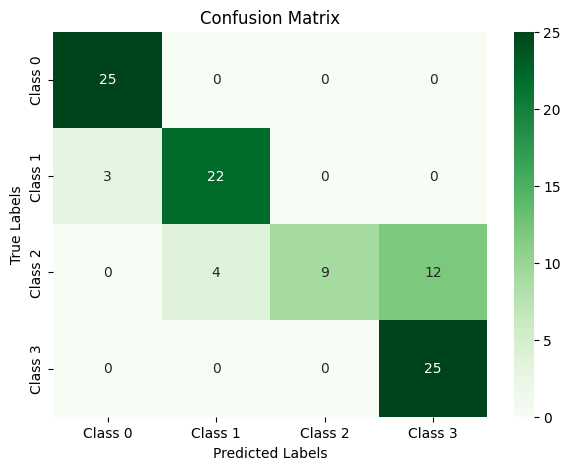

In [17]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

conf_matrix = confusion_matrix(y_test, y_test_pred)

# Plot confusion matrix 
plt.figure(figsize=(7, 5))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Greens', xticklabels=['Class 0', 'Class 1', 'Class 2', 'Class 3'], yticklabels=['Class 0', 'Class 1', 'Class 2', 'Class 3'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

#### Receiver Operating Characteristic (ROC) Curve

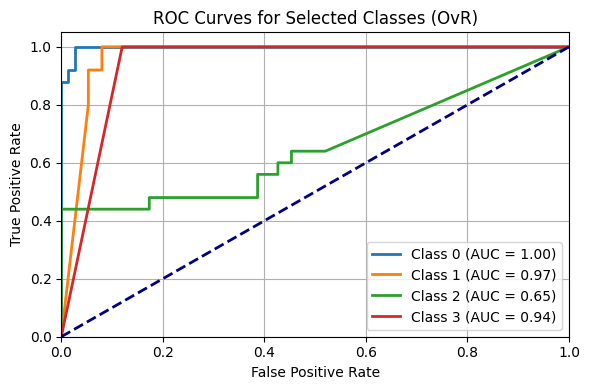

In [18]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

selected_classes = [0, 1, 2, 3]
plt.figure(figsize=(6, 4))

for class_label in selected_classes:
    y_test_binary = (y_test == class_label).astype(int)
    fpr, tpr, thresholds = roc_curve(y_test_binary, y_test_pred_proba_nb[:, class_label])
    roc_auc = auc(fpr, tpr)
    
    # Customize κάθε κλάση
    plt.plot(fpr, tpr, label=f'Class {class_label} (AUC = {roc_auc:.2f})', 
             color=plt.cm.get_cmap('tab10')(class_label), linestyle='-', linewidth=2)

# Plot the diagonal line 
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Selected Classes (OvR)')
plt.legend(loc='lower right')

plt.grid(True)
plt.tight_layout()
plt.show()

#### Precision, Recall, F1 Score, Accuracy

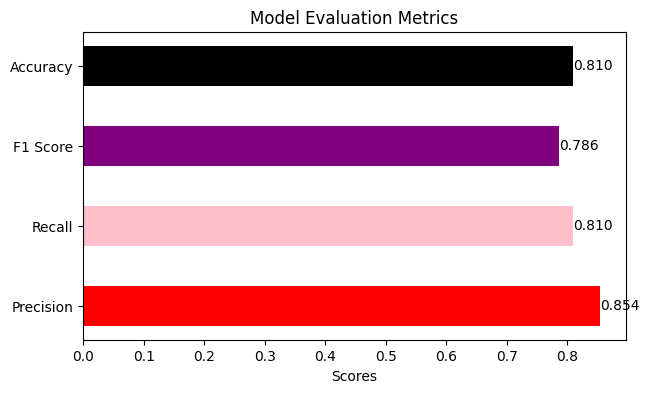

In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
metrics = ['Precision', 'Recall', 'F1 Score', 'Accuracy']
scores = [precision_test_nb, recall_test_nb, f1_test_nb, accuracy_test_nb]
bar_width = 0.5

# Plot horizontal bars
bars = ax.barh(metrics, scores, height=bar_width, color=['red', 'pink', 'purple', 'black'])

# Display actual values 
for bar in bars:
    plt.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, f'{bar.get_width():.3f}', 
             va='center', ha='left', color='black')

ax.set_xlabel('Scores')
ax.set_title('Model Evaluation Metrics')

plt.show()

#### 5fold Cross Validation

In [30]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_validate, KFold
import numpy as np

nb_5fold = GaussianNB()
kf = KFold(n_splits=5, shuffle=True, random_state=42)

scoring_metrics = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted', 'neg_log_loss', 'roc_auc_ovo_weighted']

cv_results = cross_validate(nb_5fold, X_dataset, y_dataset, cv=kf, scoring=scoring_metrics, return_train_score=False)

for fold in range(1, kf.get_n_splits() + 1):
    print(f"Fold {fold} Metrics:")
    print(f"Accuracy: {cv_results['test_accuracy'][fold-1]}")
    print(f"Precision: {cv_results['test_precision_weighted'][fold-1]}")
    print(f"Recall: {cv_results['test_recall_weighted'][fold-1]}")
    print(f"F1 Score: {cv_results['test_f1_weighted'][fold-1]}")
    print(f"Log Loss: {abs(np.mean(cv_results['test_neg_log_loss'][fold-1]))}")
    print(f"ROC AUC: {cv_results['test_roc_auc_ovo_weighted'][fold-1]}")
    print("--" * 100)

mean_metrics = {metric: np.mean(cv_results[f'test_{metric}']) for metric in scoring_metrics}

print("Mean Metrics Across Folds:")
for metric, value in mean_metrics.items():
    if metric == 'neg_log_loss':
        value = abs(value)
    print(f"{metric}: {value}")


Fold 1 Metrics:
Accuracy: 0.7
Precision: 0.7331816059757236
Recall: 0.7
F1 Score: 0.6646537018833414
Log Loss: 3.6538658300808478
ROC AUC: nan
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Fold 2 Metrics:
Accuracy: 0.6
Precision: 0.6872646237178257
Recall: 0.6
F1 Score: 0.5621082296710637
Log Loss: 4.211508688574502
ROC AUC: nan
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Fold 3 Metrics:
Accuracy: 0.6214285714285714
Precision: 0.6346031746031746
Recall: 0.6214285714285714
F1 Score: 0.5467896772048306
Log Loss: 5.473101177321474
ROC AUC: nan
---------------------------------------------------------------------------------------------------------------------------------------------

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


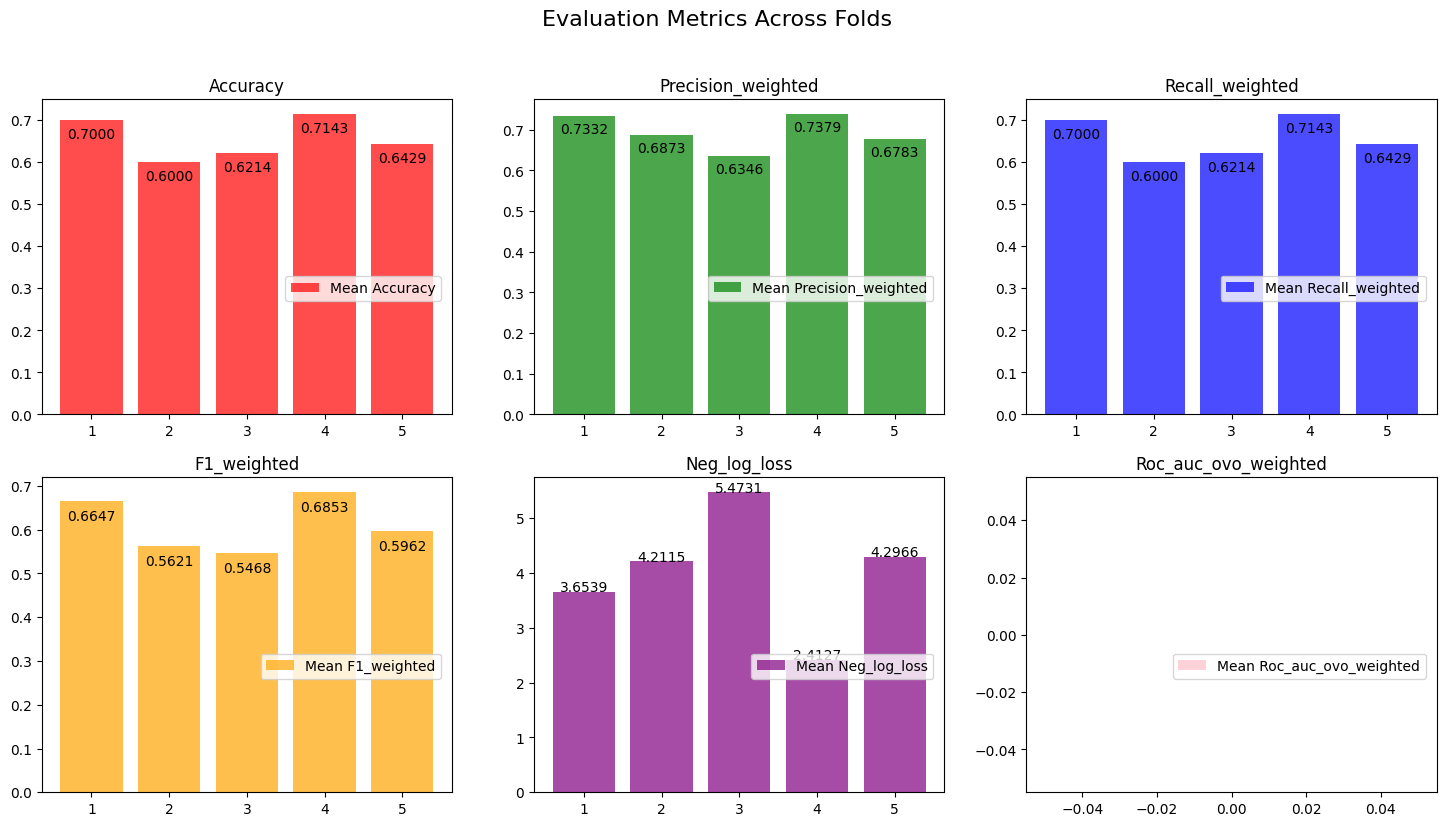

In [31]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 9))
fig.suptitle('Evaluation Metrics Across Folds', fontsize=16)

# Function for values inside the bars
def add_values(ax, values):
    for i, value in enumerate(values):
        ax.text(i + 1, value - 0.05, f'{value:.4f}', ha='center', va='bottom', color='black')

bar_height = 0.5
metrics_to_plot = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted', 'neg_log_loss', 'roc_auc_ovo_weighted']
colors = ['red', 'green', 'blue', 'orange', 'purple', 'pink']  

for idx, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    row = idx // 3
    col = idx % 3

    if metric == 'neg_log_loss':
        metric_values = np.abs(cv_results[f'test_{metric}'])
    else:
        metric_values = cv_results[f'test_{metric}']

    bars = axes[row, col].bar(range(1, kf.get_n_splits() + 1), metric_values, color=color, alpha=0.7)
    axes[row, col].set_title(metric.capitalize())
    add_values(axes[row, col], metric_values)

    axes[row, col].legend([f'Mean {metric.capitalize()}'], loc='center right', bbox_to_anchor=(0.99, 0.4))

if len(metrics_to_plot) < 6:
    fig.delaxes(axes[-1, -1])

plt.subplots_adjust(hspace=0.2)
plt.show()
